In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3
import numpy as np

import database (sql)


In [2]:
conn=sqlite3.connect('customer_churn.db')
sql_query="""
select name from sqlite_master where type='table'
"""

In [3]:
tables=pd.read_sql(""" select name from sqlite_master where type='table' """,conn)
tables

,name
0,db_customer
1,db_subscription
2,db_support


create dataframe

In [4]:
for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f'df_{table_name}']=df
    print(f'created dataframe: df_{table_name}')
conn.close()

created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


removing the unnessary columns


In [5]:
df_db_customer.drop(columns=['interests','pincode'],inplace=True)


changin data type of dob column

In [6]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

data standardization -gender 

In [7]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

updating missing values

In [8]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [9]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

now miving on next table

In [10]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


now changin the data type of dates columns 

In [11]:
date_col=['subscription_start_date','cancellation_date','renewal_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


now the last table 

In [12]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [13]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)


changing data type of date 

In [14]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [15]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


.................................... Feature engineering and data analysis ...........................................

adding a flag to churn users

creating a new col using existing col 

In [16]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [17]:
df_db_customer.shape

(21, 6)

removing duplicates from df_db_support 

In [18]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [19]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

now merging the data

In [20]:
df=(df_db_subscription
    .merge(df_db_customer,on="customerid",how='left')
    .merge(df_db_support,on='customerid',how='left'))


In [21]:
df.shape

(21, 21)

In [22]:
df.to_csv('exported-churn-data.csv',index=False)

churn rate

In [23]:
churn_rate=df['churn_flag'].mean()*100
print("churn rate = ",round(churn_rate,2),"%")

churn rate =  28.57 %


retension rate


In [24]:
retension_rate =(100-churn_rate)
print("retension rate = ",round(retension_rate,2),"%")


retension rate =  71.43 %


In [25]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN


 3 churn by plan type 

In [26]:
churnbyplan=df.groupby('plan_type')['churn_flag'].mean().reset_index()

State wise churn rate 

In [27]:
churn_by_state=df.groupby(['state','plan_type'])['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_by_state,)

            state plan_type  churn_rate_pct
0           Delhi     Basic            0.00
1           Delhi  Standard           33.33
2       Karnataka   Premium          100.00
3       Karnataka  Standard          100.00
4       Kathmandu     Basic            0.00
5       Kathmandu  Standard            0.00
6     Maharashtra   Premium            0.00
7     Maharashtra  Standard            0.00
8       Meghalaya     Basic          100.00
9       Meghalaya   Premium            0.00
10       Nagaland   Premium            0.00
11      Rajasthan   Premium            0.00
12      Rajasthan  Standard            0.00
13      Telangana     Basic          100.00
14      Telangana  Standard            0.00
15  Uttar Pradesh   Premium            0.00


In [28]:
premium_users_in_karnataka=df[(df['state']=='Karnataka') & (df['plan_type']=="Premium")][['customerid','name']]
print(premium_users_in_karnataka)

   customerid    name
1  0003-MKNFE  raghav


totle revenue

In [29]:
totle_revenue=df['monthly_charges'].sum()
totle_revenue.round(2)

np.float64(395.79)

Average revenue per

In [30]:
average_revenue=df['monthly_charges'].mean()
average_revenue.round(2)

np.float64(18.85)

In [31]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

average customer tenure

In [32]:
today=pd.Timestamp.today()
df['tenure_days']=np.where(
    
   
    df['cancellation_date'].notna(),
    ( df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
    
)

In [33]:
average_tenure=df['tenure_days'].mean().round()
average_tenure


np.float64(1501.0)

revenue lost from churn user 

In [34]:
revenue_loss=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print('revenue loss in k',revenue_loss)

revenue loss in k 73.94


Esclation rate 

In [35]:
exclation_rate=(df['escalations']=='Y').mean()*100
exclation_rate.round(2),"%"

(np.float64(19.05), '%')

Average complaint per user

In [36]:
avg_complaints_per_user=df['complaint_count'].fillna(0).sum() /df['customerid'].nunique()
(avg_complaints_per_user*100)

np.float64(42.857142857142854)

Correlation  Escaltion vs churn 

In [37]:
df['escalations'] = np.where(df['escalations'] == "Y", 1, 0)

corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

round(correlation, 2)

np.float64(0.77)

Churn risk - create a coloum using existing col

In [38]:
conditions =[
    
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
    
]

choices=['low','medium','high']
df['churn_risk']= np.select(conditions,choices,default='unknown')

In [39]:
df[['churn_score','churn_risk']].head()
df[df['churn_risk']=='high'][['churn_score','churn_risk']]

,churn_score,churn_risk
1,91,high
4,88,high
6,79,high
11,83,high
13,76,high
18,99,high


.....................Data visualization .......................

In [40]:
df_visual=df.copy()

Monthly churn rate 

Text(0, 0.5, 'Churned customers')

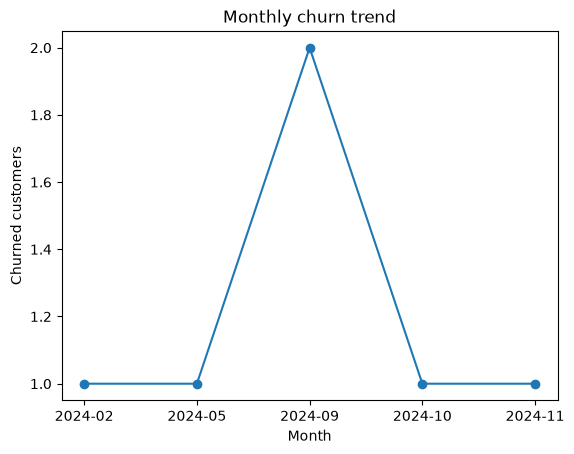

In [41]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.plot(churn_trend.index.astype(str),churn_trend.values,marker='o')
plt.title("Monthly churn trend")
plt.xlabel('Month')
plt.ylabel("Churned customers")
#plt.savefig("Montly Churn trend")


churn by plan type 

In [42]:
import plotly.express as px

churn_plan = (
    df_visual.groupby('plan_type')['churn_flag']
    .mean()
    .reset_index()
)

churn_plan['churn_rate'] = churn_plan['churn_flag'] * 100

fig = px.bar(
    churn_plan,
    x='plan_type',
    y='churn_rate',
    text='churn_rate',
    title='Churn Rate by Plan Type',
    labels={
        'plan_type': 'Plan Type',
        'churn_rate': 'Churn Rate (%)'
    },
    hover_data={'churn_rate': ':.2f'}
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    yaxis_range=[0, 100],
    hovermode='x unified'
)

fig.show()
#plt.savefig("Churn Rate by plan type")

churn b states 

In [43]:
import plotly.express as px

churn_states = (
    df_visual.groupby('state')['churn_flag']
    .mean()
    .reset_index()
)

churn_states['churn_rate'] = churn_states['churn_flag'] * 100

fig = px.bar(
    churn_states,
    x='churn_rate',
    y='state',
    orientation='h',
    text='churn_rate',
    title='Churn Rate by State',
    labels={
        'churn_rate': 'Churn Rate (%)',
        'state': 'State'
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_range=[0, 100]
)

fig.show()
#plt.savefig('churn rate by states')

heatmap(correlation )

In [44]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [45]:
df_encoded=df_visual[[
        'plan_type', 'contract_type',
        'churn_score',
       'churn_flag', 
       'escalations','churn_risk']]
order_mapping ={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
    
}
for col,order in order_mapping.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
df_encoded.head()


C:\Users\dell\AppData\Local\Temp\ipykernel_16092\588959536.py:13: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes


,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

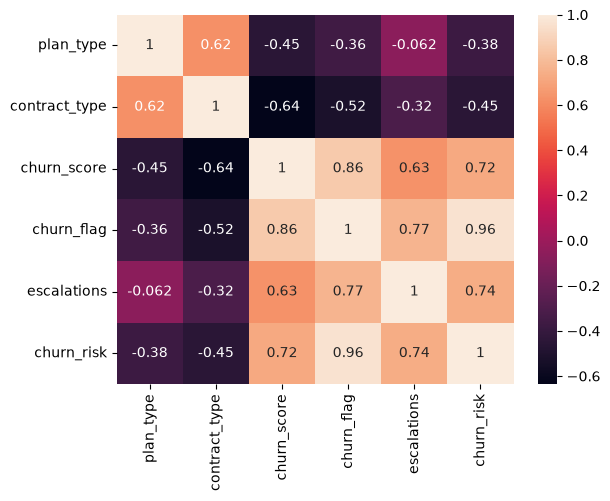

In [46]:
sns.heatmap(df_encoded.corr(),annot=True)
#plt.savefig("correlation")